In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd()  

sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / "py_modules"))

from pipeline_config import MAPS_DIR, FIGS_DIR
import results_comp

In [2]:
def plot_param_grid_lines_as_x(
    data_in,
    *,
    params=("sig2", "r0", "m", "noise", "s0"),
    line_order=("H", "N", "O", "S", "S2", "Ar"),
    group_order=("KPNO", "MUSE trim", "MUSE"),
    line_labels=None,
    param_labels=None,
    param_titles=None,
    param_ylims=None,
    row_titles=("Physical parameters", "Nuisance parameters"),
    row_title_fontsize=16,
    row_title_y=1.22,
    decimals=4,
    figsize=(15, 8),
    color_palette="Greys_d",
    markers=("o", "s", "^"),
    jitter=0.10,
    capsize=4,
    elinewidth=1.8,
    markersize=7,
    legend_fontsize=13,
    legend_title_fontsize=14,
    show_values=False,
    true=None,
    save=False,
    savepath="fit_parameters_lines_as_x.pdf",
):
    """
    Plot fit parameters with emission line on the x-axis.

    Layout
    ------
    First row:
        sig2, r0, m

    Second row:
        noise, s0, legend

    Encoding
    --------
    x-axis:
        emission line, e.g. H, N, O, S, S2, Ar

    marker/color:
        sample group, e.g. KPNO, MUSE trim, MUSE

    Expected data_in format
    -----------------------
    Each entry must contain:

        entry["line"]
        entry["group"]
        entry["fit_dict"]

    where fit_dict has entries like:

        fit_dict["sig2"] = [value, upper_error, lower_error]

    Parameters
    ----------
    line_labels : None, dict, list, or tuple
        Custom x-axis labels for emission lines.

        Example:
            line_labels = {
                "H": r"H$\\alpha$",
                "N": r"[N II]",
                "O": r"[O III]",
                "S": r"[S III]",
                "S2": r"[S II]",
                "Ar": r"[Ar III]",
            }

    param_labels : None or dict
        Custom y-axis labels with units.

        Example:
            param_labels = {
                "sig2": r"$\\sigma^2$ [km$^2$ s$^{-2}$]",
                "r0": r"$r_0$ [pc]",
                "m": r"$m$",
                "noise": r"$B_\\mathrm{noise}$ [km$^2$ s$^{-2}$]",
                "s0": r"$s_0$ [pc]",
            }

    param_titles : None or dict
        Custom subplot titles. If None, compact default titles are used.

    param_ylims : None or dict
        Custom y-axis limits for each parameter.

        Example:
            param_ylims = {
                "sig2": (0, 20),
                "r0": (0, 0.15),
                "m": (0.5, 2.0),
                "noise": (0, 2),
                "s0": (0, 0.02),
            }

    row_titles : tuple, list, or None
        Row titles for the first and second rows.

        Example:
            row_titles=("Physical parameters", "Nuisance parameters")

        If None, no row titles are added.
    """

    import numpy as np
    import seaborn as sns
    from matplotlib import pyplot as plt

    if len(data_in) == 0:
        raise ValueError("data_in is empty.")

    # ------------------------------------------------------------
    # Color and marker maps by group
    # ------------------------------------------------------------
    colors = sns.color_palette(
        color_palette,
        n_colors=len(group_order),
    )[::-1]

    color_map = {
        group: colors[i]
        for i, group in enumerate(group_order)
    }

    marker_map = {
        group: markers[i % len(markers)]
        for i, group in enumerate(group_order)
    }

    # Symmetric jitter offsets centered around zero
    if len(group_order) > 1:
        jitter_offsets = np.linspace(
            -jitter,
            jitter,
            len(group_order),
        )
    else:
        jitter_offsets = np.array([0.0])

    jitter_map = {
        group: jitter_offsets[i]
        for i, group in enumerate(group_order)
    }

    # ------------------------------------------------------------
    # x-axis positions for each emission line
    # ------------------------------------------------------------
    line_x = {
        line: i
        for i, line in enumerate(line_order)
    }

    if line_labels is None:
        line_labels_final = list(line_order)

    elif isinstance(line_labels, dict):
        line_labels_final = [
            line_labels.get(line, line)
            for line in line_order
        ]

    elif isinstance(line_labels, (list, tuple)):
        if len(line_labels) != len(line_order):
            raise ValueError(
                "If line_labels is a list/tuple, it must have the same "
                "length as line_order."
            )
        line_labels_final = list(line_labels)

    else:
        raise TypeError("line_labels must be None, a dict, list, or tuple.")

    # ------------------------------------------------------------
    # Parameter titles and y-axis labels
    # ------------------------------------------------------------
    default_param_titles = {
        "sig2": r"$\sigma^2$",
        "r0": r"$r_0$",
        "m": r"$m$",
        "noise": r"$B_\mathrm{noise}$",
        "s0": r"$s_0$",
    }

    default_param_labels = {
        "sig2": r"$\sigma^2$ [km$^2$ s$^{-2}$]",
        "r0": r"$r_0$ [pc]",
        "m": r"$m$",
        "noise": r"$B_\mathrm{noise}$ [km$^2$ s$^{-2}$]",
        "s0": r"$s_0$ [pc]",
    }

    if param_titles is None:
        param_titles_final = default_param_titles
    else:
        param_titles_final = {
            **default_param_titles,
            **param_titles,
        }

    if param_labels is None:
        param_labels_final = default_param_labels
    else:
        param_labels_final = {
            **default_param_labels,
            **param_labels,
        }

    # ------------------------------------------------------------
    # Y-axis limits
    # ------------------------------------------------------------
    if param_ylims is None:
        param_ylims_final = {}
    elif isinstance(param_ylims, dict):
        param_ylims_final = param_ylims
    else:
        raise TypeError("param_ylims must be None or a dictionary.")

    # ------------------------------------------------------------
    # Optional reference values
    # ------------------------------------------------------------
    if true is None:
        true_map = {}

    elif isinstance(true, dict):
        true_map = true

    elif isinstance(true, (list, tuple)):
        true_keys = ["sig2", "r0", "m"]
        true_map = {
            key: value
            for key, value in zip(true_keys, true)
        }

    else:
        raise TypeError("true must be None, a dict, list, or tuple.")

    # ------------------------------------------------------------
    # Figure layout
    # ------------------------------------------------------------
    fig, axes = plt.subplots(
        2,
        3,
        figsize=figsize,
        sharex=False,
    )

    axes = axes.ravel()

    param_to_axis = {
        "sig2": axes[0],
        "r0": axes[1],
        "m": axes[2],
        "noise": axes[3],
        "s0": axes[4],
    }

    # ------------------------------------------------------------
    # Main plotting loop
    # ------------------------------------------------------------
    for param in params:
        if param not in param_to_axis:
            continue

        ax = param_to_axis[param]

        for entry in data_in:
            fit_dict = entry["fit_dict"]
            line = entry.get("line", None)
            group = entry.get("group", None)

            if line not in line_x:
                continue

            if group not in group_order:
                continue

            if param not in fit_dict:
                continue

            value = round(float(fit_dict[param][0]), decimals)
            upper = max(0.0, round(float(fit_dict[param][1]), decimals))
            lower = max(0.0, round(float(fit_dict[param][2]), decimals))

            x = line_x[line] + jitter_map[group]

            ax.errorbar(
                x,
                value,
                yerr=[[lower], [upper]],
                fmt=marker_map[group],
                color=color_map[group],
                markerfacecolor=color_map[group],
                markeredgecolor="black",
                markeredgewidth=0.6,
                markersize=markersize,
                capsize=capsize,
                elinewidth=elinewidth,
                linestyle="none",
            )

            if show_values:
                ax.text(
                    x,
                    value,
                    f"{value:.{decimals}f}",
                    ha="center",
                    va="bottom",
                    fontsize=8,
                )

        if param in true_map and true_map[param] is not None:
            ax.axhline(
                true_map[param],
                color="red",
                linestyle="--",
                linewidth=1.2,
                label="Reference",
            )

        ax.set_title(
            param_titles_final.get(param, param) + " vs emission line"
        )
        ax.set_ylabel(param_labels_final.get(param, param))
        ax.grid(alpha=0.3)

        # Apply custom y-axis range if requested
        if param in param_ylims_final and param_ylims_final[param] is not None:
            ax.set_ylim(param_ylims_final[param])

    # ------------------------------------------------------------
    # Common x-axis formatting
    # ------------------------------------------------------------
    x_positions = np.arange(len(line_order))

    for ax in axes[:5]:
        ax.set_xticks(x_positions)
        ax.set_xticklabels(line_labels_final, rotation=45)
        ax.set_xlim(-0.5, len(line_order) - 0.5)
        ax.set_xlabel("Emission line")

    # ------------------------------------------------------------
    # Row titles
    # ------------------------------------------------------------
    if row_titles is not None:
        if len(row_titles) != 2:
            raise ValueError("row_titles must contain exactly two entries.")

        axes[1].annotate(
            row_titles[0],
            xy=(0.5, row_title_y),
            xycoords="axes fraction",
            ha="center",
            va="center",
            fontsize=row_title_fontsize,
            fontweight="bold",
        )

        axes[4].annotate(
            row_titles[1],
            xy=(0.5, row_title_y),
            xycoords="axes fraction",
            ha="center",
            va="center",
            fontsize=row_title_fontsize,
            fontweight="bold",
        )

    # ------------------------------------------------------------
    # Legend in the empty sixth panel
    # ------------------------------------------------------------
    legend_ax = axes[5]
    legend_ax.axis("off")

    legend_handles = []

    used_groups = {
        entry.get("group", None)
        for entry in data_in
    }

    for group in group_order:
        if group not in used_groups:
            continue

        handle = plt.Line2D(
            [0],
            [0],
            marker=marker_map[group],
            color="none",
            markerfacecolor=color_map[group],
            markeredgecolor="black",
            markeredgewidth=0.6,
            markersize=markersize + 2,
            label=group,
        )

        legend_handles.append(handle)

    if len(legend_handles) > 0:
        legend_ax.legend(
            handles=legend_handles,
            loc="center",
            frameon=False,
            title="Sample",
            fontsize=legend_fontsize,
            title_fontsize=legend_title_fontsize,
            markerscale=1.4,
            handlelength=1.5,
            labelspacing=1.1,
        )

    fig.tight_layout()

    if save:
        fig.savefig(savepath, bbox_inches="tight")

    return fig, axes

In [28]:
# ------------------------------------------------------------
# Fit-limit definitions
# ------------------------------------------------------------
fit_limits = (0.3, 0.4, 0.5, 0.6, 0.7, 0.8)

line_order = ("N","S","Ar", "H", "O")

file_line_ids = {
    "N": "N",
    "S": "S",
    "Ar": "Ar",
    "H": "H",
    "O": "O",
}

# Labels used by plot_param_grid_lines_as_x as the "groups"
fit_limit_labels = {
    fit_limit: rf"$r_\mathrm{{max}} = {fit_limit:.1f}L$"
    for fit_limit in fit_limits
}

group_order = tuple(
    fit_limit_labels[fit_limit]
    for fit_limit in fit_limits
)


# ------------------------------------------------------------
# Construct the 15 explicit samples
# ------------------------------------------------------------
samples_explicit = []

for line in line_order:
    file_line = file_line_ids[line]

    for fit_limit in fit_limits:

        # 0.3 -> "03", 0.4 -> "04", etc.
        fit_tag = f"{int(round(10 * fit_limit)):02d}"

        file_name = (
            f"MUSE-M42-{file_line}-bin2_{fit_tag}"
        )

        samples_explicit.append(
            {
                "file_name": file_name,
                "label": f"MUSE {line} trim {fit_tag}",
                "line": line,
                "group": fit_limit_labels[fit_limit],
                "fit_limit": fit_limit,
                "internal_name": (
                    f"MUSE_M42_{line}_bin2_trim_{fit_tag}"
                ),
            }
        )


# Optional: inspect the filenames before loading
for sample in samples_explicit:
    print(
        sample["line"],
        sample["fit_limit"],
        sample["file_name"],
    )

N 0.3 MUSE-M42-N-bin2_03
N 0.4 MUSE-M42-N-bin2_04
N 0.5 MUSE-M42-N-bin2_05
N 0.6 MUSE-M42-N-bin2_06
N 0.7 MUSE-M42-N-bin2_07
N 0.8 MUSE-M42-N-bin2_08
S 0.3 MUSE-M42-S-bin2_03
S 0.4 MUSE-M42-S-bin2_04
S 0.5 MUSE-M42-S-bin2_05
S 0.6 MUSE-M42-S-bin2_06
S 0.7 MUSE-M42-S-bin2_07
S 0.8 MUSE-M42-S-bin2_08
Ar 0.3 MUSE-M42-Ar-bin2_03
Ar 0.4 MUSE-M42-Ar-bin2_04
Ar 0.5 MUSE-M42-Ar-bin2_05
Ar 0.6 MUSE-M42-Ar-bin2_06
Ar 0.7 MUSE-M42-Ar-bin2_07
Ar 0.8 MUSE-M42-Ar-bin2_08
H 0.3 MUSE-M42-H-bin2_03
H 0.4 MUSE-M42-H-bin2_04
H 0.5 MUSE-M42-H-bin2_05
H 0.6 MUSE-M42-H-bin2_06
H 0.7 MUSE-M42-H-bin2_07
H 0.8 MUSE-M42-H-bin2_08
O 0.3 MUSE-M42-O-bin2_03
O 0.4 MUSE-M42-O-bin2_04
O 0.5 MUSE-M42-O-bin2_05
O 0.6 MUSE-M42-O-bin2_06
O 0.7 MUSE-M42-O-bin2_07
O 0.8 MUSE-M42-O-bin2_08


In [29]:
fit_limit = sample.get("fit_limit", None)

In [30]:
def load_explicit_result_samples(
    results_comp,
    maps_dir,
    samples,
    *,
    read_header=True,
    fit_key="fit",
):
    """
    Load an explicit list of fit-result samples.
    """

    data_in = []

    for sample in samples:
        file_name = sample["file_name"]
        label = sample.get("label", file_name)
        line = sample.get("line")
        group = sample.get("group")
        fit_limit = sample.get("fit_limit")

        internal_name = sample.get(
            "internal_name",
            f"{label}_line".replace(" ", "_").replace("-", "_"),
        )

        bundle = results_comp.load_line_bundle_mat(
            file_name,
            internal_name,
            maps_dir,
            read_header=read_header,
        )

        fit = bundle[fit_key]
        fit_dict = fit.to_dict(orient="list")

        entry = {
            "line": line,
            "label": label,
            "group": group,
            "fit_limit": fit_limit,
            "file_name": file_name,
            "bundle": bundle,
            "fit": fit,
            "fit_dict": fit_dict,
            "meta": bundle.get("meta", {}),
        }

        data_in.append(entry)

    return data_in

In [31]:
data_fit_limits = load_explicit_result_samples(
    results_comp,
    MAPS_DIR,
    samples_explicit,
    read_header=True,
)

print(f"Successfully loaded {len(data_fit_limits)} samples")

Successfully loaded 30 samples


In [32]:
for entry in data_fit_limits:
    print(
        entry["line"],
        entry["fit_limit"],
        entry["file_name"],
        list(entry["fit"].columns),
    )

N 0.3 MUSE-M42-N-bin2_03 ['sig2', 'r0', 'm', 's0', 'noise']
N 0.4 MUSE-M42-N-bin2_04 ['sig2', 'r0', 'm', 's0', 'noise']
N 0.5 MUSE-M42-N-bin2_05 ['sig2', 'r0', 'm', 's0', 'noise']
N 0.6 MUSE-M42-N-bin2_06 ['sig2', 'r0', 'm', 's0', 'noise']
N 0.7 MUSE-M42-N-bin2_07 ['sig2', 'r0', 'm', 's0', 'noise']
N 0.8 MUSE-M42-N-bin2_08 ['sig2', 'r0', 'm', 's0', 'noise']
S 0.3 MUSE-M42-S-bin2_03 ['sig2', 'r0', 'm', 's0', 'noise']
S 0.4 MUSE-M42-S-bin2_04 ['sig2', 'r0', 'm', 's0', 'noise']
S 0.5 MUSE-M42-S-bin2_05 ['sig2', 'r0', 'm', 's0', 'noise']
S 0.6 MUSE-M42-S-bin2_06 ['sig2', 'r0', 'm', 's0', 'noise']
S 0.7 MUSE-M42-S-bin2_07 ['sig2', 'r0', 'm', 's0', 'noise']
S 0.8 MUSE-M42-S-bin2_08 ['sig2', 'r0', 'm', 's0', 'noise']
Ar 0.3 MUSE-M42-Ar-bin2_03 ['sig2', 'r0', 'm', 's0', 'noise']
Ar 0.4 MUSE-M42-Ar-bin2_04 ['sig2', 'r0', 'm', 's0', 'noise']
Ar 0.5 MUSE-M42-Ar-bin2_05 ['sig2', 'r0', 'm', 's0', 'noise']
Ar 0.6 MUSE-M42-Ar-bin2_06 ['sig2', 'r0', 'm', 's0', 'noise']
Ar 0.7 MUSE-M42-Ar-bin2_07 ['sig

In [33]:
# ------------------------------------------------------------
# Plot labels and limits
# ------------------------------------------------------------
param_labels = {
    "sig2": r"$\sigma^2$ [km$^2$ s$^{-2}$]",
    "r0": r"$r_0$ [pc]",
    "m": r"$m$",
    "noise": r"$B_\mathrm{noise}$ [km$^2$ s$^{-2}$]",
    "s0": r"$s_0$ [pc]",
}

param_titles = {
    "sig2": r"$\sigma^2$",
    "r0": r"$r_0$",
    "m": r"$m$",
    "noise": r"$B_\mathrm{noise}$",
    "s0": r"$s_0$",
}

line_labels = {
    "N": r"[N II]",
    "S": r"[S III]",
    "Ar": r"[Ar III]",
    "H": r"H$\alpha$",
    "O": r"[O III]",
}

param_ylims = {
    "sig2": (4, 12),
    "r0": (0, 0.15),
    "m": (0.5, 1.5),
    "noise": (0, 15),
    "s0": (0, 0.0035),
}

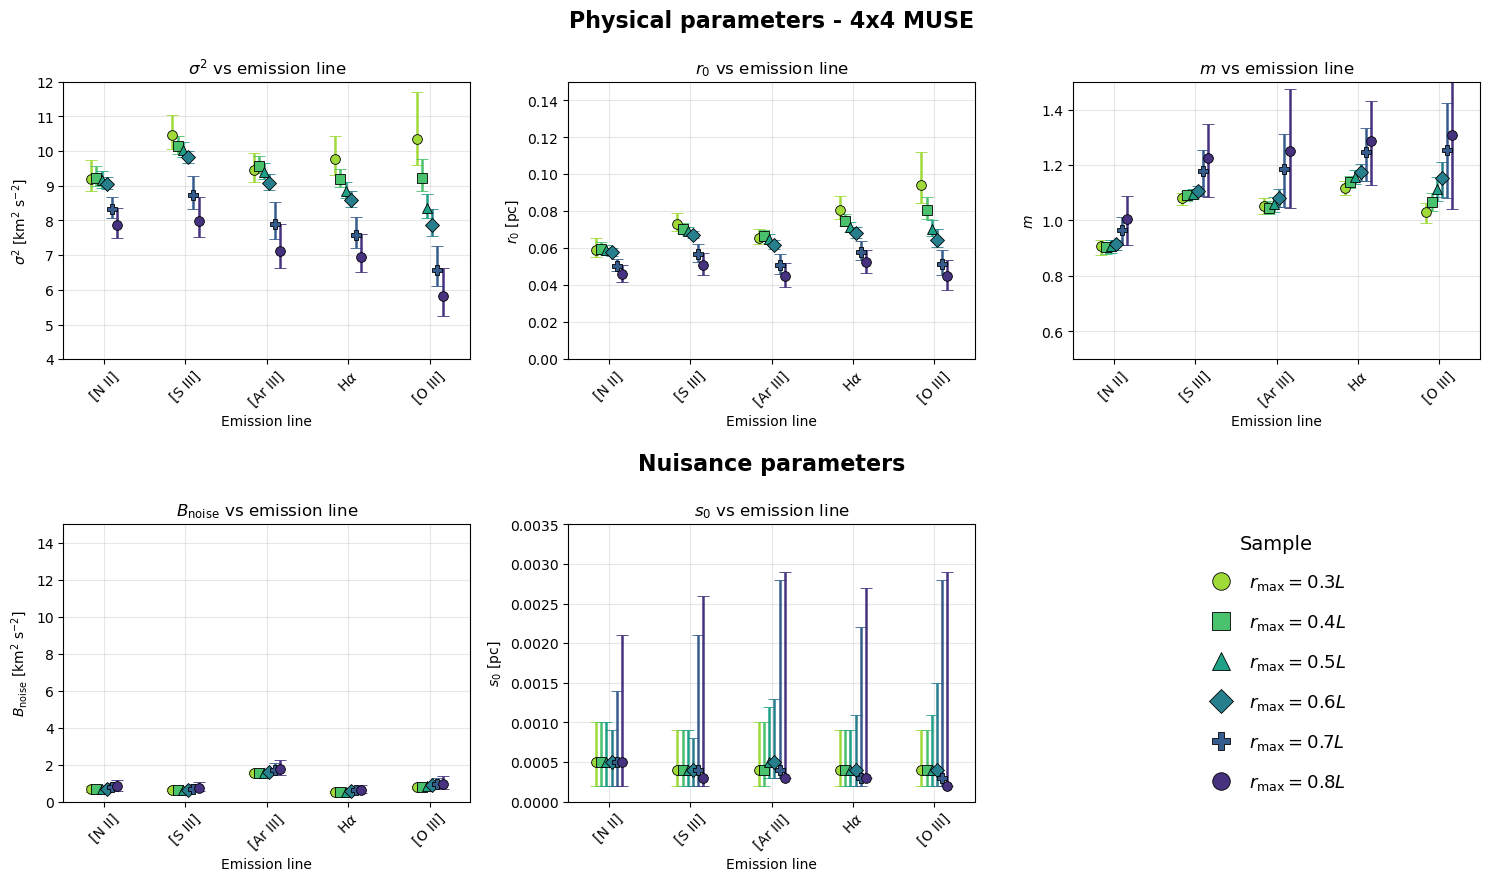

In [35]:
fig, axes = plot_param_grid_lines_as_x(
    data_fit_limits,
    # X-axis and legend order
    line_order=("N", "S", "Ar", "H", "O"),
    group_order=group_order,
    # Labels
    line_labels=line_labels,
    param_labels=param_labels,
    param_titles=param_titles,
    # Axis limits
    param_ylims=param_ylims,
    # Row labels
    row_titles=(
        "Physical parameters - 4x4 MUSE",
        "Nuisance parameters",
    ),
    row_title_fontsize=16,
    row_title_y=1.22,
    # Appearance
    decimals=4,
    figsize=(15, 9),
    color_palette="viridis",
    markers=("o", "s", "^", "D", "P"),
    jitter=0.16,
    capsize=4,
    elinewidth=1.8,
    markersize=7,
    # Output
    save=True,
    savepath="Imgs/fit_parameters_fit_limit_comparison_bin2.jpg",
)